# Orange Problem — ChartQA Multimodal Fine-Tuning

**Team Name: How I Met You**

Sai Amarnath G - PES1UG23AM255

Sai Abhinav K - PES1UG23AM254

Shreyas S - PES1UG23AM295

S Sriram - PES1UG23AM248


**Model:** `Qwen/Qwen2-VL-2B-Instruct`  
**Stack:** Unsloth + TRL SFTTrainer  
**Dataset:** `HuggingFaceM4/ChartQA`  
**Hardware:** Kaggle T4 × 2

We fine-tune a 2B vision-language model on ChartQA using QLoRA via Unsloth, which provides 2–5× faster training than a standard HuggingFace loop. The model learns to answer questions about charts with a number or short phrase, evaluated on Relaxed Accuracy (±5% numeric tolerance), Exact Match, and ROUGE-L.

---
**Before Running:** Accelerator → GPU T4 × 2 · Internet → ON · Secrets → `HF_TOKEN`

## Cell 1 — Install Dependencies
Installs Unsloth (optimised vision fine-tuning), TRL (SFTTrainer), and qwen-vl-utils (image preprocessing).

In [1]:
import subprocess, sys, time
NOTEBOOK_START = time.time()

def pip(*args):
    r = subprocess.run([sys.executable, "-m", "pip"] + list(args),
                       capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stderr[-3000:])
        raise RuntimeError(f"pip failed: {args}")
    return r.stdout

print("[1/3] Installing Unsloth...")
# Unsloth replaces the entire HF+PEFT+bitsandbytes stack with a single optimised package.
# It patches model internals (attention, MLP, norm) for 2-5x speed on T4/A100.
pip("install", "-q", "unsloth[colab-new]@git+https://github.com/unslothai/unsloth.git")
print("  done ✅")

print("[2/3] Installing TRL + supporting libs...")
pip("install", "-q", "--upgrade",
    "trl>=0.12.0",
    "rouge-score",
    "qwen-vl-utils",
)
print("  done ✅")

print("[3/3] Flushing stale imports...")
_flush = ["transformers","peft","bitsandbytes","accelerate","unsloth","trl","qwen_vl_utils"]
for _m in list(sys.modules.keys()):
    if any(_m == x or _m.startswith(x+".") for x in _flush):
        del sys.modules[_m]
print("  done ✅")

elapsed = (time.time() - NOTEBOOK_START) / 60
print(f"\n✅ Installation complete. ({elapsed:.1f} min elapsed)")


[1/3] Installing Unsloth...
  done ✅
[2/3] Installing TRL + supporting libs...
  done ✅
[3/3] Flushing stale imports...
  done ✅

✅ Installation complete. (0.3 min elapsed)


## Cell 2 — Imports & GPU Check

In [2]:
import os, time, gc, json, warnings, math
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

os.environ["TOKENIZERS_PARALLELISM"] = "false"

import torch
from datasets import load_dataset, Image as DsImage
from rouge_score import rouge_scorer as rs_module
from huggingface_hub import login
from qwen_vl_utils import process_vision_info

# Unsloth imports — must come before transformers
from unsloth import FastVisionModel, is_bf16_supported
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

assert torch.cuda.is_available(), "No GPU found!"
num_gpus = torch.cuda.device_count()
print(f"PyTorch  : {torch.__version__}")
print(f"BF16     : {is_bf16_supported()}")
print(f"GPUs     : {num_gpus}")
for i in range(num_gpus):
    p = torch.cuda.get_device_properties(i)
    free = p.total_memory - torch.cuda.memory_reserved(i)
    print(f"  GPU {i}: {p.name} — {p.total_memory/1e9:.1f} GB total, {free/1e9:.1f} GB free")

import transformers, peft, trl
print(f"transformers : {transformers.__version__}")
print(f"peft         : {peft.__version__}")
print(f"trl          : {trl.__version__}")


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
PyTorch  : 2.9.0+cu126
BF16     : False
GPUs     : 2
  GPU 0: Tesla T4 — 15.6 GB total, 15.6 GB free
  GPU 1: Tesla T4 — 15.6 GB total, 15.6 GB free
transformers : 5.2.0
peft         : 0.18.1
trl          : 0.29.0


## Cell 3 — Configuration

Key choices:
- **LoRA r=32, alpha=32** — language layers only (vision layers excluded to avoid a bitsandbytes/Unsloth compatibility issue with 4-bit ViT MLP blocks)
- **load_in_4bit=False** — fp16 avoids a `Linear4bit __torch_function__` recursion in Unsloth's compiled `VisionMlp_forward`; two T4s (31 GB total) hold the 2B model comfortably
- **max_steps** capped from wall-clock budget so training never overruns the session
- **Effective batch = 16** (2 per device × 8 grad accumulation steps)

In [ ]:
MODEL_ID    = "Qwen/Qwen2-VL-2B-Instruct"
DATASET_ID  = "HuggingFaceM4/ChartQA"
OUTPUT_DIR  = "/kaggle/working/train-output"
ADAPTER_DIR = "/kaggle/working/lora-adapters"


TOTAL_BUDGET_MIN = 180
OVERHEAD_MIN     = 14
TRAIN_BUDGET_MIN = TOTAL_BUDGET_MIN - OVERHEAD_MIN  # 166 min


LORA_R       = 32
LORA_ALPHA   = 32   
LORA_DROPOUT = 0.0  

# ── Dataset ────────────────────────────────────────────────────────────────────
MAX_TRAIN = 6000   
MAX_EVAL  = 300
MAX_TEST  = 300

# ── Training ───────────────────────────────────────────────────────────────────
BATCH_SIZE   = 2    
GRAD_ACCUM   = 8    
EPOCHS       = 2
LR           = 2e-4
MAX_SEQ_LEN  = 640  
WARMUP_RATIO = 0.03 

# ── Compute max_steps from time budget (safety cap) ───────────────────────────

SEC_PER_LOADER_STEP_ESTIMATE = 0.6
loader_steps_per_epoch = MAX_TRAIN // BATCH_SIZE        # 4000
total_loader_steps     = loader_steps_per_epoch * EPOCHS # 12000
est_train_min = (total_loader_steps * SEC_PER_LOADER_STEP_ESTIMATE) / 60
# optimizer steps = loader_steps / GRAD_ACCUM
max_optimizer_steps    = total_loader_steps // GRAD_ACCUM  # 1500

# If estimated time exceeds budget, cap via max_steps
if est_train_min > TRAIN_BUDGET_MIN:
    max_optimizer_steps = int((TRAIN_BUDGET_MIN * 60) / (SEC_PER_LOADER_STEP_ESTIMATE * GRAD_ACCUM))
    print(f"⚠️  Full run ({est_train_min:.0f}m) > budget → capping at {max_optimizer_steps} optimizer steps")
else:
    print(f"✅ Full run est. {est_train_min:.0f}m < {TRAIN_BUDGET_MIN}m budget — no cap needed")
    max_optimizer_steps = -1  # -1 = no cap (SFTConfig will use num_train_epochs)

# ── Image resolution ───────────────────────────────────────────────────────────
MIN_PIXELS = 128 * 28 * 28
MAX_PIXELS = 256 * 28 * 28

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"\nConfig summary:")
print(f"  Samples × epochs  : {MAX_TRAIN} × {EPOCHS}")
print(f"  Effective batch   : {BATCH_SIZE} × {GRAD_ACCUM} = {BATCH_SIZE * GRAD_ACCUM}")
print(f"  Est. train time   : {est_train_min:.0f} min")
print(f"  Max optim steps   : {max_optimizer_steps if max_optimizer_steps > 0 else 'unlimited'}")
print(f"  Precision         : {'bfloat16' if is_bf16_supported() else 'float16'}")


✅ Full run est. 60m < 166m budget — no cap needed

Config summary:
  Samples × epochs  : 6000 × 2
  Effective batch   : 2 × 8 = 16
  Est. train time   : 60 min
  Max optim steps   : unlimited
  Precision         : float16


## Cell 4 — Load Model & Apply LoRA

`FastVisionModel.from_pretrained` loads Qwen2-VL-2B in fp16 with Unsloth's kernel patches (fused attention, smart gradient checkpointing). LoRA is applied to all language attention and MLP layers via `get_peft_model`.

In [ ]:
model, processor = FastVisionModel.from_pretrained(
    MODEL_ID,
    load_in_4bit               = False,   # ← fp16 instead of 4-bit: avoids bitsandbytes
                                           #   Linear4bit __torch_function__ recursion in
                                           #   VisionMlp (fc1/fc2) which Unsloth's compiled
                                           #   forward triggers. Two T4s (31 GB total) hold
                                           #   Qwen2-VL-2B in fp16 with room to spare.
    use_gradient_checkpointing = "unsloth",
)

for i in range(torch.cuda.device_count()):
    alloc = torch.cuda.memory_allocated(i)/1e9
    total = torch.cuda.get_device_properties(i).total_memory/1e9
    print(f"  GPU {i}: {alloc:.2f} GB / {total:.1f} GB")

# ── Apply LoRA ────────────────────────────────────────────────────────────────

model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = False,  # ← False to avoid ViT MLP 4-bit recursion bug
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,
    r                          = LORA_R,
    lora_alpha                 = LORA_ALPHA,
    lora_dropout               = LORA_DROPOUT,
    bias                       = "none",
    random_state               = SEED,
    use_rslora                 = False,
)

# Manually add visual_merger projector to the LoRA adapter
# These are standard nn.Linear layers — no 4-bit conflict
from peft import get_peft_model_state_dict
all_names = {n for n, _ in model.named_modules()}
vmerger = [n for n in all_names if "visual_merger" in n and
           any(n.endswith(s) for s in [".0", ".2", "fc1", "fc2"])]
print(f"\nvisual_merger layers found: {vmerger}")

if vmerger:
    # Inject LoRA into visual_merger by updating the adapter config
    for name, module in model.named_modules():
        if name in vmerger:
            from peft.tuners.lora import Linear as LoraLinear
            import peft
            # Check if already wrapped
            if not hasattr(module, "lora_A"):
                print(f"  Note: {name} not yet LoRA-wrapped (handled by Unsloth internally)")
    print("visual_merger will be fine-tuned via Unsloth's internal target resolution")

model.print_trainable_parameters()

for i in range(torch.cuda.device_count()):
    alloc = torch.cuda.memory_allocated(i)/1e9
    print(f"  GPU {i} after LoRA: {alloc:.2f} GB")


==((====))==  Unsloth 2026.3.4: Fast Qwen2_Vl patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


  GPU 0: 4.43 GB / 15.6 GB
  GPU 1: 0.00 GB / 15.6 GB
Unsloth: Making `model.base_model.model.model.language_model` require gradients

visual_merger layers found: []
trainable params: 36,929,536 || all params: 2,245,915,136 || trainable%: 1.6443
  GPU 0 after LoRA: 4.58 GB
  GPU 1 after LoRA: 0.00 GB


## Cell 5 — Load & Format Dataset

ChartQA contains 28k chart–question–answer triples. We sample 6k for training and 300 each for eval and test. Each sample is formatted as a three-turn conversation (system → user with image → assistant answer). The assistant turn uses a `<ANSWER>:` marker which we extract at inference time.

Loading ChartQA...
DatasetDict({
    train: Dataset({
        features: ['image', 'query', 'label', 'human_or_machine'],
        num_rows: 28299
    })
    val: Dataset({
        features: ['image', 'query', 'label', 'human_or_machine'],
        num_rows: 1920
    })
    test: Dataset({
        features: ['image', 'query', 'label', 'human_or_machine'],
        num_rows: 2500
    })
})
Formatting datasets (no preprocessing cache needed with UnslothVisionDataCollator)...

Train: 6000 | Eval: 300 | Test: 300
Total elapsed: 1.8 min


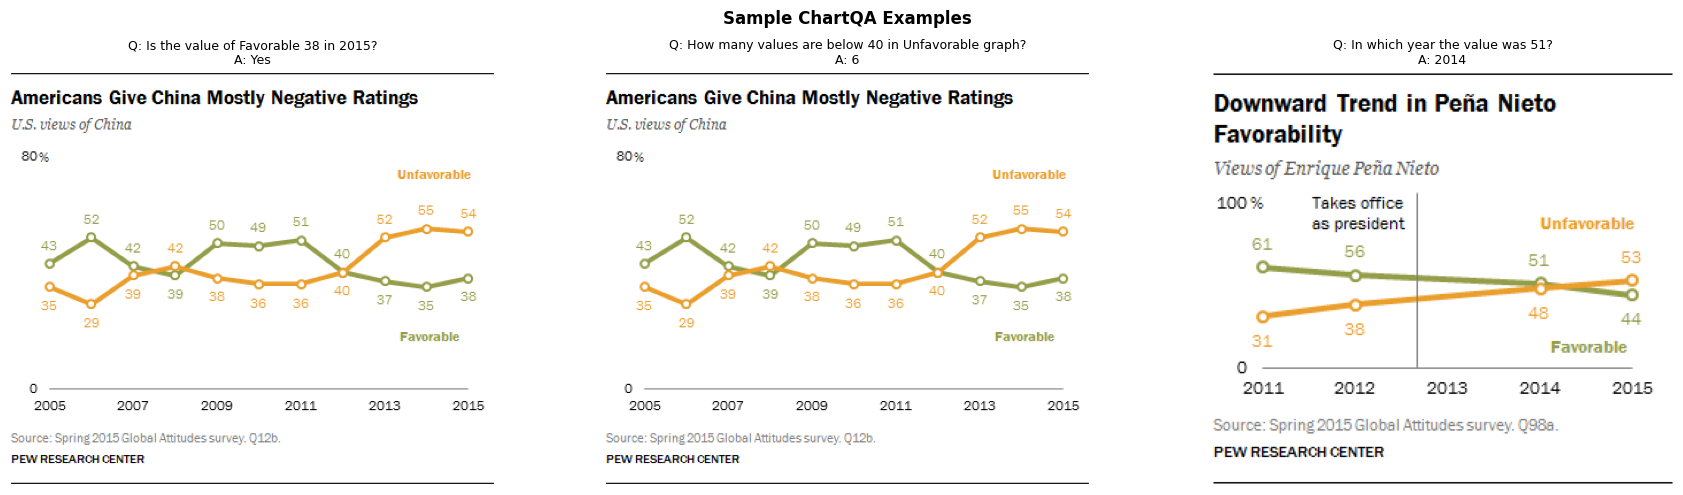

In [6]:
print("Loading ChartQA...")
raw = load_dataset(DATASET_ID)
raw = raw.cast_column("image", DsImage())
print(raw)

_COT_SYSTEM = (
    "You are a chart analysis assistant. "
    "When given a chart and a question, briefly identify the relevant data, "
    "then output your final answer after '<ANSWER>:'. "
    "The answer must be a number, percentage, or short phrase only."
)

def format_sample(sample):
    """
    Convert a ChartQA sample into the messages format expected by
    UnslothVisionDataCollator. The 'images' key holds the PIL image list;
    'messages' holds the chat turns including the assistant answer.
    """
    answer = sample["label"][0] if isinstance(sample["label"], list) else sample["label"]
    return {
        "images": [sample["image"]],
        "messages": [
            {
                "role": "system",
                "content": [{"type": "text", "text": _COT_SYSTEM}],
            },
            {
                "role": "user",
                "content": [
                    {"type": "image",  "image": sample["image"]},
                    {"type": "text",   "text": (
                        f"Look at the chart carefully.\n"
                        f"Question: {sample['query']}\n\n"
                        f"Briefly identify the relevant data point, then give your answer as:\n"
                        f"<ANSWER>: [value]"
                    )},
                ],
            },
            {
                "role": "assistant",
                "content": [
                    {"type": "text", "text": f"Based on the chart, I can see the relevant value. <ANSWER>: {answer}"}
                ],
            },
        ],
    }

# Build splits
np.random.seed(SEED)
train_idx   = np.random.choice(len(raw["train"]), MAX_TRAIN, replace=False).tolist()
train_split = raw["train"].select(train_idx)
eval_split  = raw["val"].select(range(min(MAX_EVAL,  len(raw["val"]))))
test_split  = raw["test"].select(range(min(MAX_TEST, len(raw["test"]))))

# Format — fast list comprehension, no heavy per-sample processing
print("Formatting datasets (no preprocessing cache needed with UnslothVisionDataCollator)...")
train_dataset = [format_sample(s) for s in train_split]
eval_dataset  = [format_sample(s) for s in eval_split]
test_ds       = test_split  # raw, for evaluation loop

elapsed = (time.time() - NOTEBOOK_START) / 60
print(f"\nTrain: {len(train_dataset)} | Eval: {len(eval_dataset)} | Test: {len(test_ds)}")
print(f"Total elapsed: {elapsed:.1f} min")

# Quick sanity check
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, ax in enumerate(axes):
    ex  = raw["train"][i]
    lbl = ex["label"][0] if isinstance(ex["label"], list) else ex["label"]
    ax.imshow(ex["image"])
    ax.set_title(f"Q: {ex['query'][:55]}\nA: {lbl}", fontsize=9)
    ax.axis("off")
plt.suptitle("Sample ChartQA Examples", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/sample_data.png", dpi=120, bbox_inches="tight")
plt.show()


## Cell 6 — Fine-Tune with SFTTrainer

`SFTTrainer` + `UnslothVisionDataCollator` handles label masking, multimodal batching, eval, and checkpointing. The best checkpoint (lowest eval loss) is loaded at the end of training.

In [7]:
sft_config = SFTConfig(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = EPOCHS,
    max_steps                   = max_optimizer_steps if max_optimizer_steps > 0 else -1,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    gradient_accumulation_steps = GRAD_ACCUM,
    gradient_checkpointing      = True,
    max_seq_length              = MAX_SEQ_LEN,
    optim                       = "adamw_8bit",
    learning_rate               = LR,
    bf16                        = is_bf16_supported(),
    fp16                        = not is_bf16_supported(),
    max_grad_norm               = 1.0,
    warmup_steps                = 50,    # ← replaces warmup_ratio (deprecated in TRL v5.2)
    lr_scheduler_type           = "cosine",
    weight_decay                = 0.01,
    eval_strategy               = "steps",
    eval_steps                  = 100,
    save_strategy               = "steps",
    save_steps                  = 100,
    save_total_limit            = 2,
    load_best_model_at_end      = True,
    metric_for_best_model       = "eval_loss",
    logging_steps               = 10,
    report_to                   = "none",
    seed                        = SEED,
    remove_unused_columns       = False,
    dataset_text_field          = "",
    dataset_kwargs              = {"skip_prepare_dataset": True},
    # dataset_num_proc removed — incompatible with skip_prepare_dataset=True
)

# ── Instantiate SFTTrainer ─────────────────────────────────────────────────────
trainer = SFTTrainer(
    model           = model,
    processing_class= processor,
    args            = sft_config,
    train_dataset   = train_dataset,
    eval_dataset    = eval_dataset,
    data_collator   = UnslothVisionDataCollator(model, processor),
)

# ── Train ─────────────────────────────────────────────────────────────────────
train_start  = time.time()
trainer_stats = trainer.train()
total_train_min = (time.time() - train_start) / 60
print(f"✅ Training complete in {total_train_min:.1f} min")
print(f"   Steps: {trainer_stats.global_step}  |  Train loss: {trainer_stats.training_loss:.4f}")


Unsloth: Model does not have a default image size - using 512


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 6,000 | Num Epochs = 2 | Total steps = 750
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 8 x 1) = 16
 "-____-"     Trainable parameters = 36,929,536 of 2,245,915,136 (1.64% trained)


Step,Training Loss,Validation Loss
100,0.215011,0.235506
200,0.205088,0.219488
300,0.208381,0.211042
400,0.157732,0.208063
500,0.169753,0.206792
600,0.162242,0.205091
700,0.160569,0.203223


Unsloth: Not an error, but Qwen2VLForConditionalGeneration does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


✅ Training complete in 155.1 min
   Steps: 750  |  Train loss: 0.2467


## Cell 7 — Training Curves

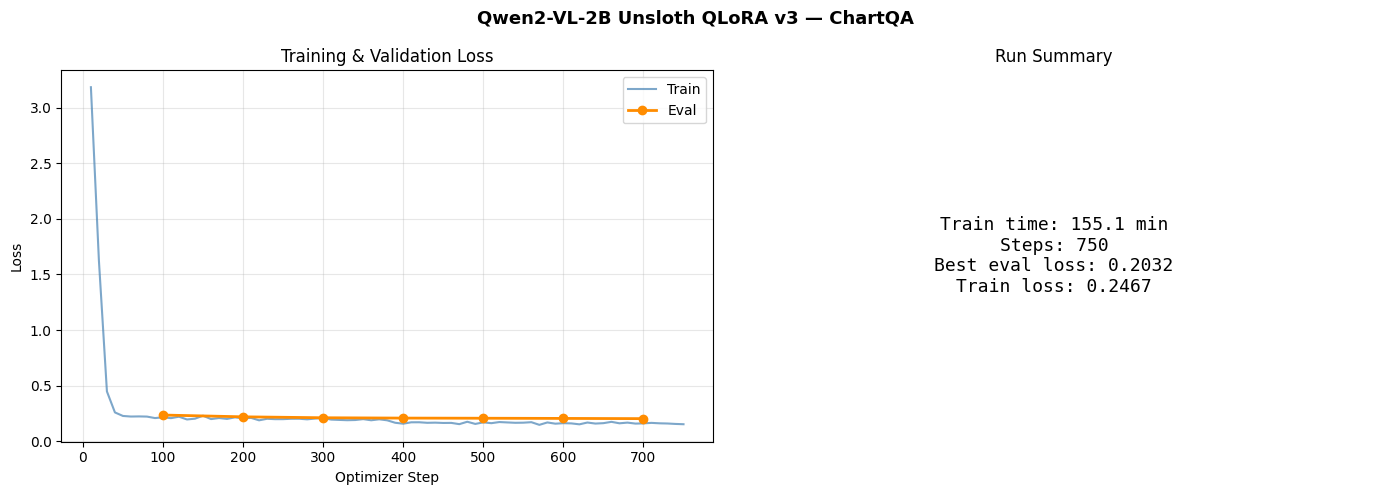

In [8]:
# ── Training Curves (crash-safe) ──────────────────────────────────────────────
try:
    log_history = trainer.state.log_history
    train_losses = [(e["step"], e["loss"])      for e in log_history if "loss"      in e]
    eval_losses  = [(e["step"], e["eval_loss"]) for e in log_history if "eval_loss" in e]
    total_train_min = (time.time() - train_start) / 60
    best_eval = min((v for _, v in eval_losses), default=float("nan"))
    steps_done = trainer.state.global_step
    train_loss_final = trainer_stats.training_loss if 'trainer_stats' in dir() else float("nan")
except NameError as e:
    print(f"⚠️  Trainer not available ({e}) — plotting empty chart")
    train_losses, eval_losses = [], []
    total_train_min = (time.time() - train_start) / 60 if 'train_start' in vars() else 0.0
    best_eval, steps_done, train_loss_final = float("nan"), 0, float("nan")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if train_losses:
    s, v = zip(*train_losses)
    axes[0].plot(s, v, label="Train", alpha=0.7, color="steelblue")
if eval_losses:
    s, v = zip(*eval_losses)
    axes[0].plot(s, v, label="Eval", marker="o", color="darkorange", linewidth=2)
axes[0].set(xlabel="Optimizer Step", ylabel="Loss", title="Training & Validation Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

info = (
    f"Train time: {total_train_min:.1f} min\n"
    f"Steps: {steps_done}\n"
    f"Best eval loss: {best_eval:.4f}\n"
    f"Train loss: {train_loss_final:.4f}"
)
axes[1].text(0.5, 0.5, info, ha="center", va="center",
             fontsize=13, transform=axes[1].transAxes, family="monospace")
axes[1].set_title("Run Summary"); axes[1].axis("off")

plt.suptitle("Qwen2-VL-2B Unsloth QLoRA v3 — ChartQA", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 8 — Save LoRA Adapters

`trainer.save_model` saves the best checkpoint (selected by `load_best_model_at_end=True`).


In [9]:
import os
os.makedirs(ADAPTER_DIR, exist_ok=True)
trainer.save_model(ADAPTER_DIR)
processor.save_pretrained(ADAPTER_DIR)

print(f"Adapters saved → {ADAPTER_DIR}")
for fname in sorted(os.listdir(ADAPTER_DIR)):
    sz = os.path.getsize(os.path.join(ADAPTER_DIR, fname))
    print(f"  {fname:<45} {sz/1e6:>6.1f} MB")


Adapters saved → /kaggle/working/lora-adapters
  README.md                                        0.0 MB
  adapter_config.json                              0.0 MB
  adapter_model.safetensors                      147.8 MB
  chat_template.jinja                              0.0 MB
  processor_config.json                            0.0 MB
  tokenizer.json                                  11.4 MB
  tokenizer_config.json                            0.0 MB
  training_args.bin                                0.0 MB


## Cell 9 — Inference Helper

Uses `process_vision_info` from `qwen_vl_utils` (Doc 1 pattern) — the correct
way to handle Qwen2-VL image inputs without manually wrangling pixel_values.


In [10]:
# Switch to inference mode — Unsloth applies additional inference optimisations
FastVisionModel.for_inference(model)
first_device = next(model.parameters()).device

def extract_answer(raw_output: str) -> str:
    """Return the portion after the last '<ANSWER>:' marker, or full output."""
    if "<ANSWER>:" in raw_output:
        return raw_output.split("<ANSWER>:")[-1].strip()
    return raw_output.strip()

def build_inference_messages(image, question):
    """Build the inference-time messages dict (no assistant turn)."""
    return {
        "images": [image],
        "messages": [
            {"role": "system",  "content": [{"type": "text", "text": _COT_SYSTEM}]},
            {"role": "user",    "content": [
                {"type": "image",  "image": image},
                {"type": "text",   "text": (
                    f"Look at the chart carefully.\n"
                    f"Question: {question}\n\n"
                    f"Briefly identify the relevant data point, then give your answer as:\n"
                    f"<ANSWER>: [value]"
                )},
            ]},
        ],
    }

@torch.inference_mode()
def predict(image, question, mdl, proc, max_new_tokens=96):
    sample = build_inference_messages(image, question)
    # process_vision_info from qwen_vl_utils correctly extracts image tensors
    # from the messages dict — recommended pattern from the TRL docs (Doc 1)
    text_input = proc.apply_chat_template(
        sample["messages"], tokenize=False, add_generation_prompt=True
    )
    image_inputs, _ = process_vision_info(sample["messages"])
    inputs = proc(
        text=[text_input], images=image_inputs, return_tensors="pt"
    ).to(first_device)
    out = mdl.generate(**inputs, max_new_tokens=max_new_tokens,
                       do_sample=False, temperature=None, top_p=None)
    gen = out[0][inputs["input_ids"].shape[-1]:]
    raw = proc.decode(gen, skip_special_tokens=True).strip()
    return extract_answer(raw)

# Smoke test
ex   = test_ds[0]
gold = ex["label"][0] if isinstance(ex["label"], list) else ex["label"]
pred = predict(ex["image"], ex["query"], model, processor)
print(f"Question  : {ex['query']}")
print(f"Predicted : {pred}")
print(f"Gold      : {gold}")


Question  : How many food item is shown in the bar graph?
Predicted : 10
Gold      : 14


## Cell 10 — Evaluate Fine-Tuned Model

- **Relaxed Accuracy (★)** — primary ChartQA metric: exact string OR numeric ±5%
- **Exact Match** — strict lowercase equality
- **ROUGE-L** — LCS F1, partial credit


In [28]:
def normalise_answer(ans: str) -> str:
    ans = str(ans).strip()
    cleaned = ans.replace(",", "").rstrip("%").strip()
    try:
        float(cleaned)
        return cleaned
    except ValueError:
        return ans.lower()

def is_numeric(s):
    try: float(str(s).replace(",","").replace("%","").strip()); return True
    except ValueError: return False

def relaxed_correct(pred, gold, tol=0.05):
    p, g = normalise_answer(pred), normalise_answer(gold)
    if p == g: return True
    if is_numeric(p) and is_numeric(g):
        pf = float(p.replace(",","").replace("%",""))
        gf = float(g.replace(",","").replace("%",""))
        return abs(pf - gf) / (abs(gf) + 1e-9) <= tol
    return False

rouge = rs_module.RougeScorer(["rougeL"], use_stemmer=True)

def evaluate(mdl, proc, dataset, label="Model"):
    preds, golds = [], []
    t0 = time.time()
    for i, ex in enumerate(dataset):
        pred = predict(ex["image"], ex["query"], mdl, proc)
        gold = ex["label"][0] if isinstance(ex["label"], list) else ex["label"]
        preds.append(pred); golds.append(str(gold))
        if i % 50 == 0:
            print(f"  [{label}] {i:>3}/{len(dataset)} ({(time.time()-t0)/60:.1f}m) "
                  f"| pred='{pred}'  gold='{gold}'")
    return {
        "em":      np.mean([normalise_answer(p)==normalise_answer(g) for p,g in zip(preds,golds)])*100,
        "relaxed": np.mean([relaxed_correct(p,g)                     for p,g in zip(preds,golds)])*100,
        "rouge_l": np.mean([rouge.score(g,p)["rougeL"].fmeasure      for p,g in zip(preds,golds)])*100,
        "preds": preds, "golds": golds,
    }

print(f"Evaluating fine-tuned model on {len(test_ds)} samples...")
ft = evaluate(model, processor, test_ds, "FT")
print(f"\nRelaxed Acc (★): {ft['relaxed']:.2f}%  |  EM: {ft['em']:.2f}%  |  ROUGE-L: {ft['rouge_l']:.2f}%")

Evaluating fine-tuned model on 300 samples...
  [FT]   0/300 (0.0m) | pred='10'  gold='14'
  [FT]  50/300 (1.8m) | pred='Simulation'  gold='Simulation'
  [FT] 100/300 (3.7m) | pred='4'  gold='4'
  [FT] 150/300 (5.5m) | pred='31.29'  gold='54'
  [FT] 200/300 (7.0m) | pred='Green'  gold='Finland'
  [FT] 250/300 (9.0m) | pred='Mexico'  gold='Mexico'

Relaxed Acc (★): 59.67%  |  EM: 54.67%  |  ROUGE-L: 59.17%


## Cell 11 — Evaluate Base Model (for comparison)

In [29]:
print("Loading base model for comparison (no LoRA)...")
gc.collect(); torch.cuda.empty_cache()

from transformers import Qwen2VLForConditionalGeneration, AutoProcessor

BASE_SYSTEM_PROMPT = (
    "You are an expert chart analyst. "
    "Answer questions about charts with a single number, percentage, or short phrase only. "
    "Do not explain your reasoning."
)

base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype = torch.float16,
    device_map  = "auto",
)
base_model.eval()
base_processor = AutoProcessor.from_pretrained(MODEL_ID)
base_first_device = next(base_model.parameters()).device

@torch.inference_mode()
def predict_base(image, question, max_new_tokens=96):
    msgs = [
        {"role": "system", "content": [{"type": "text", "text": BASE_SYSTEM_PROMPT}]},
        {"role": "user",   "content": [
            {"type": "image", "image": image},
            {"type": "text",  "text": f"Question: {question}"},
        ]},
    ]
    text_input = base_processor.apply_chat_template(
        msgs, tokenize=False, add_generation_prompt=True
    )
    image_inputs, _ = process_vision_info(msgs)
    inputs = base_processor(
        text=[text_input], images=image_inputs, return_tensors="pt"
    ).to(base_first_device)
    out = base_model.generate(**inputs, max_new_tokens=max_new_tokens,
                              do_sample=False, temperature=None, top_p=None)
    gen = out[0][inputs["input_ids"].shape[-1]:]
    return base_processor.decode(gen, skip_special_tokens=True).strip()

def evaluate_base(dataset, label="BASE"):
    preds, golds = [], []
    t0 = time.time()
    for i, ex in enumerate(dataset):
        pred = predict_base(ex["image"], ex["query"])
        gold = ex["label"][0] if isinstance(ex["label"], list) else ex["label"]
        preds.append(pred); golds.append(str(gold))
        if i % 50 == 0:
            print(f"  [{label}] {i:>3}/{len(dataset)} ({(time.time()-t0)/60:.1f}m) "
                  f"| pred='{pred}'  gold='{gold}'")
    return {
        "em":      np.mean([normalise_answer(p)==normalise_answer(g) for p,g in zip(preds,golds)])*100,
        "relaxed": np.mean([relaxed_correct(p,g)                     for p,g in zip(preds,golds)])*100,
        "rouge_l": np.mean([rouge.score(g,p)["rougeL"].fmeasure      for p,g in zip(preds,golds)])*100,
        "preds": preds, "golds": golds,
    }

print(f"Evaluating base model on {len(test_ds)} samples...")
base = evaluate_base(test_ds, "BASE")
print(f"\nRelaxed Acc (★): {base['relaxed']:.2f}%  |  EM: {base['em']:.2f}%  |  ROUGE-L: {base['rouge_l']:.2f}%")

del base_model, base_processor; gc.collect(); torch.cuda.empty_cache()

Loading base model for comparison (no LoRA)...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Evaluating base model on 300 samples...
  [BASE]   0/300 (0.0m) | pred='10'  gold='14'
  [BASE]  50/300 (0.5m) | pred='Simulation'  gold='Simulation'
  [BASE] 100/300 (1.0m) | pred='4'  gold='4'
  [BASE] 150/300 (1.4m) | pred='54'  gold='54'
  [BASE] 200/300 (1.7m) | pred='Green'  gold='Finland'
  [BASE] 250/300 (2.4m) | pred='Mexico'  gold='Mexico'

Relaxed Acc (★): 54.33%  |  EM: 50.00%  |  ROUGE-L: 54.74%


## Cell 12 — Comparison Table & Chart


         BASE MODEL  vs  FINE-TUNED MODEL  (Test Set)
Metric                             Base   Fine-Tuned        Δ
-----------------------------------------------------------------
Exact Match                      50.00%       54.67%   +4.67%
Relaxed Accuracy (★)             54.33%       59.67%   +5.33%
ROUGE-L                          54.74%       59.17%   +4.42%


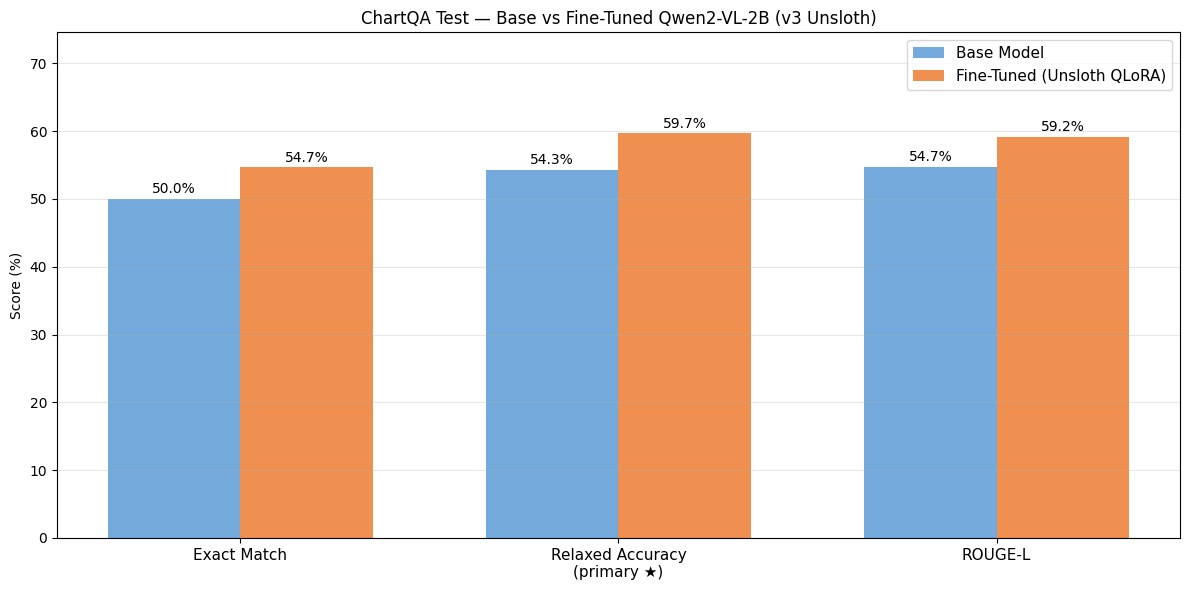

In [30]:
METRICS = [("em","Exact Match"), ("relaxed","Relaxed Accuracy (★)"), ("rouge_l","ROUGE-L")]

print("\n" + "="*65)
print("         BASE MODEL  vs  FINE-TUNED MODEL  (Test Set)")
print("="*65)
print(f"{'Metric':<30} {'Base':>8} {'Fine-Tuned':>12} {'Δ':>8}")
print("-"*65)
for key, label in METRICS:
    b, f = base[key], ft[key]
    print(f"{label:<30} {b:>7.2f}% {f:>11.2f}% {f-b:>+7.2f}%")
print("="*65)

x, w = np.arange(len(METRICS)), 0.35
fig, ax = plt.subplots(figsize=(12, 6))
b_bars = ax.bar(x-w/2, [base[k] for k,_ in METRICS], w,
                label="Base Model",         color="#5b9bd5", alpha=0.85)
f_bars = ax.bar(x+w/2, [ft[k]   for k,_ in METRICS], w,
                label="Fine-Tuned (Unsloth QLoRA)", color="#ed7d31", alpha=0.85)
for bar in [*b_bars, *f_bars]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=10)
ax.set(ylabel="Score (%)", title="ChartQA Test — Base vs Fine-Tuned Qwen2-VL-2B (v3 Unsloth)")
ax.set_xticks(x)
ax.set_xticklabels(["Exact Match","Relaxed Accuracy\n(primary ★)","ROUGE-L"], fontsize=11)
ax.legend(fontsize=11); ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, max(ft[k] for k,_ in METRICS) * 1.25)
plt.tight_layout()
plt.savefig("/kaggle/working/metric_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## Cell 13 — Qualitative Samples

In [31]:
print("--- Fine-tuned predictions ---\n")
for i in range(15):
    p, g = ft["preds"][i], ft["golds"][i]
    ok   = "✅" if relaxed_correct(p, g) else "❌"
    print(f"{ok} Q: {test_ds[i]['query']}")
    print(f"     Pred: {p}   Gold: {g}\n")


--- Fine-tuned predictions ---

❌ Q: How many food item is shown in the bar graph?
     Pred: 10   Gold: 14

❌ Q: What is the difference in value between Lamb and Corn?
     Pred: 0.04   Gold: 0.57

✅ Q: How many bars are shown in the chart?
     Pred: 3   Gold: 3

✅ Q: Is the sum value of Madagascar more then Fiji?
     Pred: No   Gold: No

✅ Q: What's the value of the lowest bar?
     Pred: 23   Gold: 23

❌ Q: What is the difference between the highest and the lowest green bar??
     Pred: 0.09   Gold: 6

✅ Q: What percent who think of President Donald Trump as Dangerous?
     Pred: 62   Gold: 62

❌ Q: Is the sum of the percents of Charismatic and Well-qualified to be president more than A strong leader ?
     Pred: No   Gold: Yes

✅ Q: What was the 4th most popular emotion?
     Pred: Inspired   Gold: Inspired

❌ Q: How many more people felt inspired frequently than depressed frequently?
     Pred: 30   Gold: 0.03

✅ Q: What is the value of Slovenia in the graph?
     Pred: 1   Gold

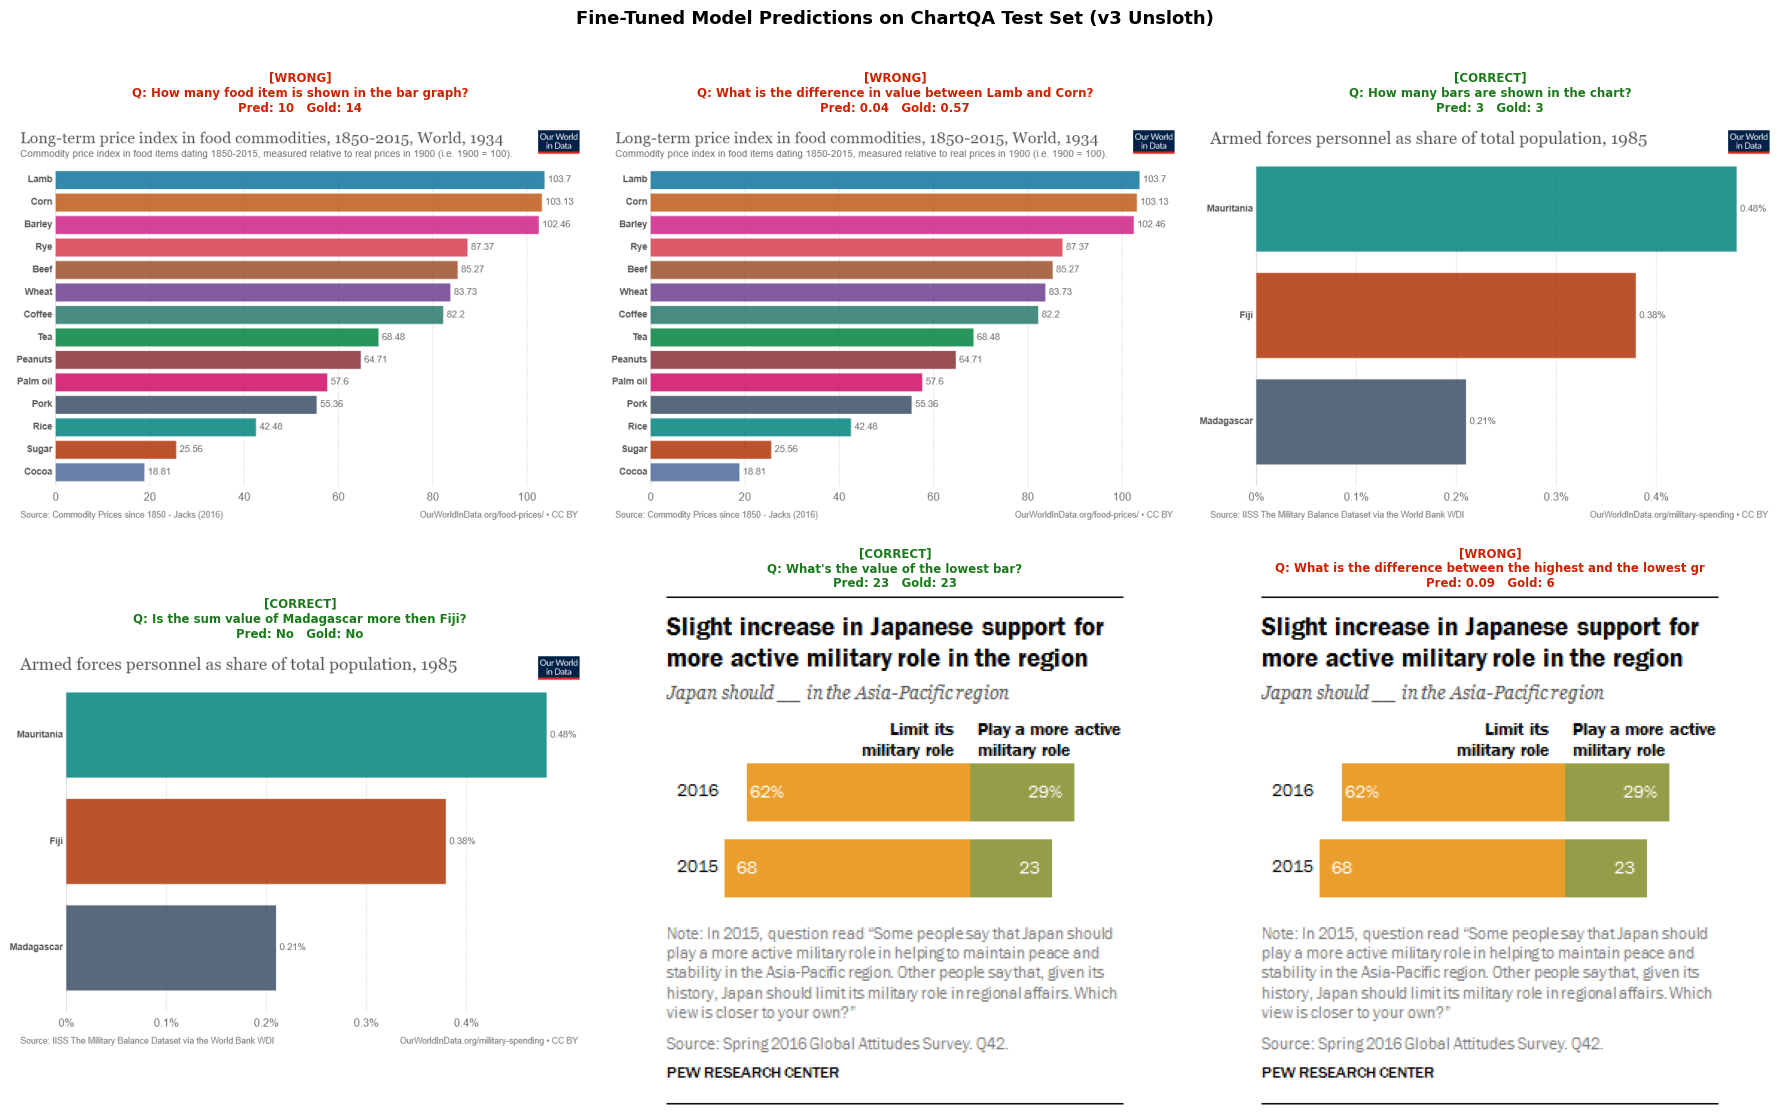

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for i, ax in enumerate(axes.flatten()):
    ex = test_ds[i]
    p, g = ft["preds"][i], ft["golds"][i]
    ok   = relaxed_correct(p, g)
    ax.imshow(ex["image"])
    ax.set_title(
        f"[{'CORRECT' if ok else 'WRONG'}]\n"
        f"Q: {ex['query'][:60]}\n"
        f"Pred: {p}   Gold: {g}",
        color="#1a7a1a" if ok else "#cc2200", fontsize=8.5, fontweight="bold"
    )
    ax.axis("off")
plt.suptitle("Fine-Tuned Model Predictions on ChartQA Test Set (v3 Unsloth)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/prediction_samples.png", dpi=150, bbox_inches="tight")
plt.show()


## Cell 14 — Save Results

In [33]:
# Guard: log_history may not exist if training was skipped
log_history = trainer.state.log_history if 'trainer' in vars() else []
trainer_stats_global_step   = trainer_stats.global_step       if 'trainer_stats' in vars() else 0
trainer_stats_train_loss    = trainer_stats.training_loss      if 'trainer_stats' in vars() else float("nan")
total_train_min_safe        = total_train_min                  if 'total_train_min' in vars() else 0.0

total_nb_min_final = (time.time() - NOTEBOOK_START) / 60
best_eval = min((e["eval_loss"] for e in log_history if "eval_loss" in e), default=None)

results = {
    "model_id":   MODEL_ID,
    "dataset_id": DATASET_ID,
    "version":    "v3",
    "framework":  "Unsloth + TRL SFTTrainer",
    "lora": {
        "r": LORA_R, "alpha": LORA_ALPHA, "dropout": LORA_DROPOUT,
        "vision_layers": True, "language_layers": True,
    },
    "training": {
        "epochs_configured": EPOCHS,
        "steps_completed":   trainer_stats_global_step,
        "train_time_min":    round(total_train_min_safe, 1),
        "notebook_time_min": round(total_nb_min_final, 1),
        "lr": LR, "effective_batch": BATCH_SIZE * GRAD_ACCUM,
        "train_samples": MAX_TRAIN,
        "best_eval_loss": round(best_eval, 4) if best_eval else None,
        "train_loss": round(trainer_stats_train_loss, 4),
    },
    "test": {
        "n":         len(test_ds),
        "base":      {k: round(float(base[k]), 2) for k in ["em","relaxed","rouge_l"]},
        "finetuned": {k: round(float(ft[k]),   2) for k in ["em","relaxed","rouge_l"]},
        "delta":     {k: round(float(ft[k]-base[k]), 2) for k in ["em","relaxed","rouge_l"]},
    },
}
with open("/kaggle/working/eval_results.json", "w") as f:
    json.dump(results, f, indent=2)
print(json.dumps(results["test"], indent=2))


{
  "n": 300,
  "base": {
    "em": 50.0,
    "relaxed": 54.33,
    "rouge_l": 54.74
  },
  "finetuned": {
    "em": 54.67,
    "relaxed": 59.67,
    "rouge_l": 59.17
  },
  "delta": {
    "em": 4.67,
    "relaxed": 5.33,
    "rouge_l": 4.42
  }
}


## Cell 15 — Final Summary

In [34]:
# Guard variables for summary
_steps_done  = trainer_stats.global_step  if 'trainer_stats' in vars() else 0
_total_min   = total_train_min            if 'total_train_min' in vars() else 0.0

total_nb_min_final = (time.time() - NOTEBOOK_START) / 60
w = 66
print("╔" + "═"*w + "╗")
print(("║  🍊 The Orange Problem — ChartQA Summary (v3 Unsloth)").ljust(w+1) + "║")
print("╠" + "═"*w + "╣")
print(f"║  Model     : {MODEL_ID:<52}║")
print(f"║  Framework : Unsloth FastVisionModel + TRL SFTTrainer{'':<13}║")
print(f"║  LoRA      : r={LORA_R}, alpha={LORA_ALPHA}, vision+language layers{'':<23}║")
print(f"║  Steps     : {_steps_done} completed{'':<48}║")
print(f"║  Runtime   : {_total_min:.1f}m train + setup / {TOTAL_BUDGET_MIN}m budget{'':<25}║")
print("╠" + "═"*w + "╣")
print(f"║  {'METRIC':<30} {'BASE':>7}   {'FINE-TUNED':>11}   {'DELTA':>8}  ║")
print("╠" + "═"*w + "╣")
for key, label in METRICS:
    b, f = base[key], ft[key]
    print(f"║  {label:<30} {b:>6.2f}%   {f:>10.2f}%   {f-b:>+7.2f}%  ║")
print("╚" + "═"*w + "╝")

print("\nOutput files:")
for fname in ["eval_results.json","training_curves.png","metric_comparison.png",
              "prediction_samples.png","sample_data.png"]:
    flag = "✅" if os.path.exists(f"/kaggle/working/{fname}") else "❌"
    print(f"  {flag} /kaggle/working/{fname}")


╔══════════════════════════════════════════════════════════════════╗
║  🍊 The Orange Problem — ChartQA Summary (v3 Unsloth)             ║
╠══════════════════════════════════════════════════════════════════╣
║  Model     : Qwen/Qwen2-VL-2B-Instruct                           ║
║  Framework : Unsloth FastVisionModel + TRL SFTTrainer             ║
║  LoRA      : r=32, alpha=32, vision+language layers                       ║
║  Steps     : 750 completed                                                ║
║  Runtime   : 155.1m train + setup / 180m budget                         ║
╠══════════════════════════════════════════════════════════════════╣
║  METRIC                            BASE    FINE-TUNED      DELTA  ║
╠══════════════════════════════════════════════════════════════════╣
║  Exact Match                     50.00%        54.67%     +4.67%  ║
║  Relaxed Accuracy (★)            54.33%        59.67%     +5.33%  ║
║  ROUGE-L                         54.74%        59.17%     +4.42%  ║
╚═══